                         id  ogc_fid  objectid     road  \
0  mrwa_road_network_2018.1        1  15162786     X001   
1  mrwa_road_network_2018.2        2  15162787     X001   
2  mrwa_road_network_2018.3        3  15162788  001Z001   
3  mrwa_road_network_2018.4        4  15162789  001Z002   
4  mrwa_road_network_2018.5        5  15162790  001Z003   

                                           road_name  \
0  High Wide Load Oversize Cross Over (Restricted...   
1  High Wide Load Oversize Cross Over (Restricted...   
2                                         Unknown Rd   
3                             Shopping Centre Access   
4                            Shamrock Station Access   

                                   common_usage_name  start_slk  end_slk  \
0  High Wide Load Oversize Cross Over (Restricted...       0.00     0.03   
1  High Wide Load Oversize Cross Over (Restricted...       0.03     0.08   
2                                         Unknown Rd       0.00     5.20   
3   

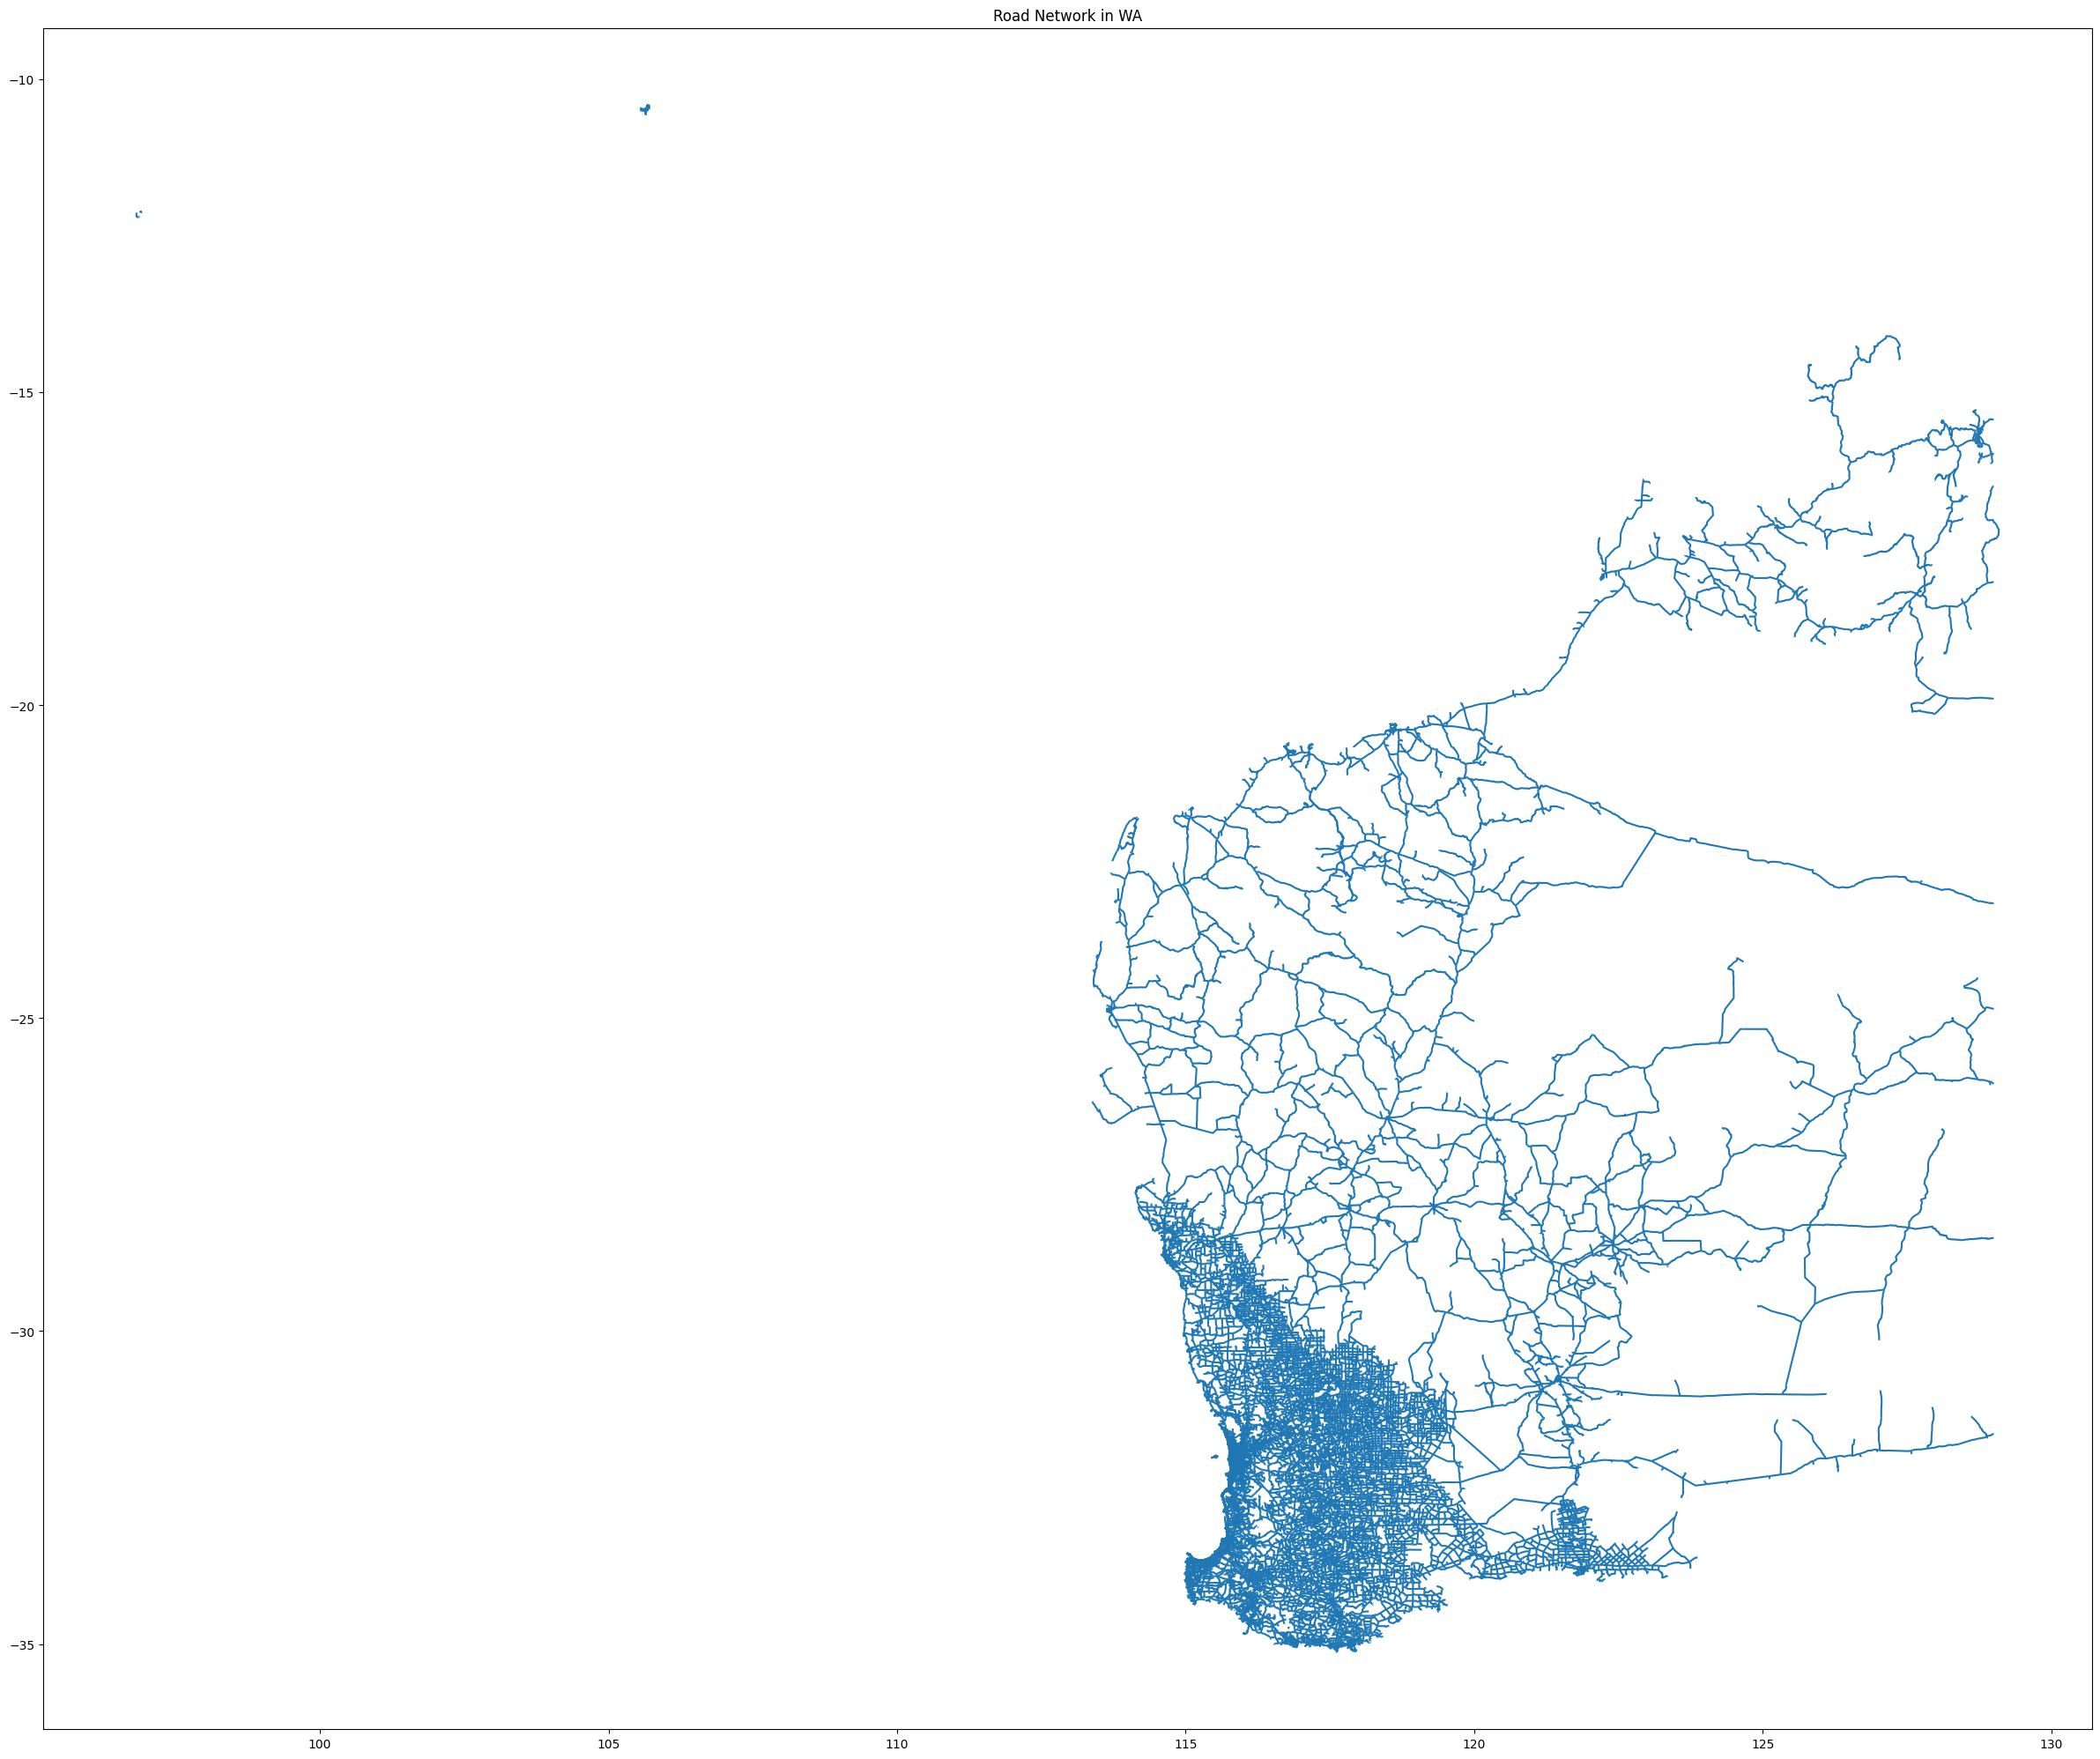

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

file_path = r"C:\Users\86183\Desktop\master\PROJECT\wa-govt-mrwa-mrwa-road-network-2018-na.json"
gdf = gpd.read_file(file_path)


print(gdf.head())

print(gdf.columns)

gdf.plot(figsize=(30, 30))
plt.title("Road Network in WA")
plt.show()


In [13]:
print(len(gdf))

176458


In [ ]:
from shapely.geometry import MultiLineString, LineString

line = gdf.geometry.iloc[0]  

if isinstance(line, LineString):
    print(list(line.coords))
elif isinstance(line, MultiLineString):
    for i, part in enumerate(line.geoms):
        print(f"Part {i+1}:")
        print(list(part.coords))
else:
    print("unknow")



Part 1:
[(116.01638682, -31.90849509), (116.01627501, -31.90857095), (116.01613373, -31.90864132)]


## Check 1： isolated road/node

In [ ]:
from collections import Counter

all_nodes = list(gdf["start_node_name"]) + list(gdf["end_node_name"])
node_counts = Counter(all_nodes)

once_nodes = [node for node, count in node_counts.items() if count == 1]

once_node_rows = gdf[gdf["start_node_name"].isin(once_nodes) | gdf["end_node_name"].isin(once_nodes)]

def both_ends_once(row):
    truly = row["start_node_name"] in once_nodes and row["end_node_name"] in once_nodes
    return truly

truly_isolated = once_node_rows[once_node_rows.apply(both_ends_once, axis=1)]
print(f"number of isolated road: {len(truly_isolated)}")


number of isolated road: 1420


In [5]:
%matplotlib qt
from shapely.geometry import Point
import geopandas as gpd
import matplotlib.pyplot as plt

# get the isolated node in  list
isolated_points = []
for geom in truly_isolated.geometry:
    if geom.geom_type == "LineString":
        isolated_points.append(Point(geom.coords[0]))      
        isolated_points.append(Point(geom.coords[-1]))     
    elif geom.geom_type == "MultiLineString":
        for line in geom.geoms:
            isolated_points.append(Point(line.coords[0]))
            isolated_points.append(Point(line.coords[-1]))

# save the node
isolated_nodes = gpd.GeoDataFrame(geometry=isolated_points, crs=gdf.crs)

fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color='blue', linewidth=0.3)
truly_isolated.plot(ax=ax, color='orange', linewidth=1.2, label='Isolated Roads')
isolated_nodes.plot(ax=ax, color='red', markersize=5, label='Isolated Nodes')
plt.title("Isolated Nodes in WA Road Network", fontsize=16)
plt.axis("off")
plt.legend()
plt.show()


In [6]:
still_isolated = []

for idx, row in truly_isolated.iterrows():
    geom = row.geometry
    # check is this road intersect with other road
    intersects = gdf[~gdf.index.isin([idx])].geometry.intersects(geom)
    if not intersects.any():
        still_isolated.append(idx)

final_isolated = truly_isolated.loc[still_isolated]
print(f"still isolate road: {len(final_isolated)}")

still isolate road: 185


In [7]:
%matplotlib qt
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 14))
gdf.plot(ax=ax, color='blue', linewidth=0.3, label='All Roads')
truly_isolated.plot(ax=ax, color='orange', linewidth=1, label='Initially Isolated')
isolated_nodes.plot(ax=ax, color='pink', markersize=5, label='Isolated Nodes')
final_isolated.plot(ax=ax, color='red', linewidth=2, label='Still Isolated (Geometry Unconnected)')
plt.title("Final Geometrically Isolated Road Segments", fontsize=15)
plt.axis("off")
plt.legend()
plt.show()



Subsequent processing of the data, if the length of the road section is greater than 0.5km retain and connect to the nearest frontal node, less than that it is removed.

## Check 2: outlier (5km around west australia)

In [8]:
from shapely.geometry import Point

#find centre of each road
centroids = gdf.geometry.centroid

# def 5km in longitude and latitude
buffer_deg = 5 / 111  # ≈ 0.045

# def west australia boundary 
min_lon, max_lon = 112 - buffer_deg, 129 + buffer_deg
min_lat, max_lat = -36 - buffer_deg, -12 + buffer_deg

# 使用逻辑判断过滤掉离群线段
outliers = gdf[
    ~centroids.apply(lambda pt: min_lon <= pt.x <= max_lon and min_lat <= pt.y <= max_lat)
]

print(f"number of outliers: {len(outliers)}")


C:\Users\86183\AppData\Local\Temp\ipykernel_3096\2713803716.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid


number of outliers: 284


## Check 3： overlapping

In [9]:
duplicates = gdf[gdf.duplicated(subset="geometry", keep=False)]
print(f"completely overlap road: {len(duplicates)}")

completely overlap road: 0


## Check 4： Straight Line Kilometre

In [ ]:
slk_length = gdf["end_slk"] - gdf["start_slk"]
true_distance = gdf["end_true_dist"] - gdf["start_true_dist"]

slk_greater = slk_length > true_distance

print(f"nuber of road slk greater than true distance：{len(slk_greater)}")

SLK 长度大于 True Distance 的道路段数量：176458


In [14]:
sample = gdf[["road_name", "start_slk", "end_slk", "start_true_dist", "end_true_dist"]].sample(10)
sample["slk_length"] = sample["end_slk"] - sample["start_slk"]
sample["true_length"] = sample["end_true_dist"] - sample["start_true_dist"]
print(sample)

              road_name  start_slk  end_slk  start_true_dist  end_true_dist  \
43716   Brandalier Turn       0.00     0.03             0.00           0.03   
134707       McInnes St       0.12     0.25             0.12           0.25   
103878      Bussell Hwy       1.79     2.04             1.79           2.04   
63355      Armstrong Rd       0.70     0.78             0.70           0.78   
48324       Connolly Dr       2.10     2.40             2.10           2.40   
162985         Pinga St       0.85     1.04             0.85           1.04   
35087         Indoon Wy       0.17     0.24             0.17           0.24   
116159    Crowea Rd (F)       0.00     0.12             0.00           0.12   
65547     Bull Creek Rd       0.22     0.29             0.22           0.29   
52710    Portchester Dr       0.22     0.29             0.22           0.29   

        slk_length  true_length  
43716         0.03         0.03  
134707        0.13         0.13  
103878        0.25         0

In [ ]:
import numpy as np

slk_length = gdf["end_slk"] - gdf["start_slk"]
true_length = gdf["end_true_dist"] - gdf["start_true_dist"]

slk_greater = slk_length > true_length + 1e-6

print(f"nuber of road slk greater than true distance：{slk_greater.sum()}")

明显大于的路段数量：0
